In [74]:
import h5py

h5_path = "F:\data\landslide\TrainData\img\image_11.h5"

with h5py.File(h5_path, "r") as f:
    # 打印文件中所有 key（类似文件夹）
    print(f)
    print("Keys:", list(f.keys()))

    # 递归打印整个结构
    def print_h5(name, obj):
        print(name, obj)

    f.visititems(print_h5)


<HDF5 file "image_11.h5" (mode r)>
Keys: ['img', 'label']
img <HDF5 dataset "img": shape (128, 128, 14), type "<f8">
label <HDF5 dataset "label": shape (1,), type "<i4">


In [ ]:
import h5py

with h5py.File(h5_path, "r") as f:
    for k in f.keys():
        print(k, f[k].shape, f[k].dtype)

img (128, 128, 14) float64


In [9]:
import numpy as np
h5_path = "F:\data\landslide\ValidData\mask\mask_4.h5"
# 统计 h5 文件中所有数据的 1 和 0 的数量
with h5py.File(h5_path, "r") as f:
    for key in f.keys():
        data = f[key][:]  # 读取全部数据
        
        # 统计 1 和 0 的数量
        count_1 = np.sum(data == 1)
        count_0 = np.sum(data == 0)
        total = data.size
        
        print(f"\n数据集: {key}")
        print(f"总元素数: {total}")
        print(f"1 的数量: {count_1}")
        print(f"0 的数量: {count_0}")
        print(f"其他数值: {total - count_1 - count_0}")
        print(f"1 的百分比: {count_1/total*100:.2f}%")
        print(f"0 的百分比: {count_0/total*100:.2f}%")


数据集: mask
总元素数: 16384
1 的数量: 430
0 的数量: 15954
其他数值: 0
1 的百分比: 2.62%
0 的百分比: 97.38%


In [53]:
import os
from pathlib import Path

# 设置要遍历的文件夹路径
folder_path = r"F:/data/landslide/ValidData-v1/mask"

# 存储结果
only_zeros_files = []
ones_less_than_10_files = []
other_files = []

# 遍历文件夹中的所有 h5 文件
for file in os.listdir(folder_path):
    if file.endswith('.h5'):
        file_path = os.path.join(folder_path, file)
        
        try:
            with h5py.File(file_path, "r") as f:
                # 读取文件中的所有数据
                all_data = []
                for key in f.keys():
                    all_data.append(f[key][:])
                
                if all_data:
                    combined_data = np.concatenate([d.flatten() for d in all_data])
                    unique_values = np.unique(combined_data)
                    count_ones = np.sum(combined_data == 1)
                    
                    # 检查是否只有 0
                    if len(unique_values) == 1 and unique_values[0] == 0:
                        only_zeros_files.append(file)
                        # print(f"✓ {file}: 只有 0")
                    # 检查1的数量是否小于10
                    elif count_ones < 10 and count_ones > 0:
                        ones_less_than_10_files.append((file, count_ones))
                        print(f"△ {file}: 1的数量 = {count_ones}")
                    else:
                        other_files.append((file, unique_values, count_ones))
                        # print(f"✗ {file}: 包含值 {unique_values}, 1的数量 = {count_ones}")
        except Exception as e:
            print(f"❌ {file}: 读取出错 - {e}")

print(f"\n{'='*50}")
print(f"统计结果:")
print(f"只有 0 的文件数: {len(only_zeros_files)}")
print(f"1的数量小于10的文件数: {len(ones_less_than_10_files)}")
print(f"其他文件数: {len(other_files)}")
# print(f"\n1的数量小于10的文件列表:")
# for f, count in ones_less_than_10_files:
#     print(f"  - {f}: 1的数量 = {count}")

△ mask_17.h5: 1的数量 = 9
△ mask_186.h5: 1的数量 = 9
△ mask_92.h5: 1的数量 = 9

统计结果:
只有 0 的文件数: 99
1的数量小于10的文件数: 3
其他文件数: 143


In [ ]:
import os
from pathlib import Path

# 设置要遍历的文件夹路径
folder_path = r"F:/data/landslide/TestData/img"

# 存储结果
only_zeros_files = []
ones_less_than_10_files = []
other_files = []

# 遍历文件夹中的所有 h5 文件
for file in os.listdir(folder_path):
    if file.endswith('.h5'):
        file_path = os.path.join(folder_path, file)
        
        try:
            with h5py.File(file_path, "r") as f:
                # 读取文件中的所有数据
                all_data = []
                for key in f.keys():
                    all_data.append(f[key][:])
                
                if all_data:
                    combined_data = np.concatenate([d.flatten() for d in all_data])
                    unique_values = np.unique(combined_data)
                    count_ones = np.sum(combined_data == 1)
                    
                    # 检查是否只有 0
                    if len(unique_values) == 1 and unique_values[0] == 0:
                        only_zeros_files.append(file)
                        # print(f"✓ {file}: 只有 0")
                    # 检查1的数量是否小于10
                    elif count_ones < 10 and count_ones > 0:
                        ones_less_than_10_files.append((file, count_ones))
                        print(f"△ {file}: 1的数量 = {count_ones}")
                    else:
                        other_files.append((file, unique_values, count_ones))
                        # print(f"✗ {file}: 包含值 {unique_values}, 1的数量 = {count_ones}")
        except Exception as e:
            print(f"❌ {file}: 读取出错 - {e}")

print(f"\n{'='*50}")
print(f"统计结果:")
print(f"只有 0 的文件数: {len(only_zeros_files)}")
print(f"1的数量小于10的文件数: {len(ones_less_than_10_files)}")
print(f"其他文件数: {len(other_files)}")
# print(f"\n1的数量小于10的文件列表:")
# for f, count in ones_less_than_10_files:
#     print(f"  - {f}: 1的数量 = {count}")

In [ ]:
import os
import h5py
import numpy as np

# 设置mask文件夹路径
mask_folder_path = r"../TrainData/mask"

# 遍历mask文件夹中的所有h5文件，计算1的数量并添加label字段
for file in os.listdir(mask_folder_path):
    if file.endswith('.h5'):
        file_path = os.path.join(mask_folder_path, file)

        try:
            with h5py.File(file_path, 'r+') as f:  # 'r+' 模式允许读写
                if 'mask' in f:
                    mask_data = f['mask'][:]
                    count_ones = np.sum(mask_data == 1)

                    # 根据1的数量设置label
                    if count_ones < 5:
                        label = 0
                    else:
                        label = 1

                    # 如果label字段不存在，则创建；否则更新
                    if 'label' in f:
                        del f['label']  # 删除现有label以便重新创建
                    f.create_dataset('label', data=np.array([label], dtype=np.int32))

                    print(f"{file}: 1的数量 = {count_ones}, 设置label = {label}")
                else:
                    print(f"{file}: 未找到'mask'数据集")
        except Exception as e:
            print(f"❌ {file}: 处理出错 - {e}")

print("所有mask文件已处理完毕，label字段已添加。")

mask_13.h5: 1的数量 = 0, 设置label = 0
mask_825.h5: 1的数量 = 152, 设置label = 1
mask_3298.h5: 1的数量 = 0, 设置label = 0
mask_310.h5: 1的数量 = 167, 设置label = 1
mask_664.h5: 1的数量 = 24, 设置label = 1
mask_304.h5: 1的数量 = 2840, 设置label = 1
mask_947.h5: 1的数量 = 365, 设置label = 1
mask_1180.h5: 1的数量 = 136, 设置label = 1
mask_2306.h5: 1的数量 = 1318, 设置label = 1
mask_2787.h5: 1的数量 = 0, 设置label = 0
mask_1402.h5: 1的数量 = 520, 设置label = 1
mask_460.h5: 1的数量 = 0, 设置label = 0
mask_1657.h5: 1的数量 = 3141, 设置label = 1
mask_2446.h5: 1的数量 = 246, 设置label = 1
mask_1431.h5: 1的数量 = 0, 设置label = 0
mask_1619.h5: 1的数量 = 1170, 设置label = 1
mask_3066.h5: 1的数量 = 353, 设置label = 1
mask_3509.h5: 1的数量 = 0, 设置label = 0
mask_3054.h5: 1的数量 = 1896, 设置label = 1
mask_229.h5: 1的数量 = 61, 设置label = 1
mask_1198.h5: 1的数量 = 408, 设置label = 1
mask_2575.h5: 1的数量 = 0, 设置label = 0
mask_869.h5: 1的数量 = 109, 设置label = 1
mask_2232.h5: 1的数量 = 1398, 设置label = 1
mask_448.h5: 1的数量 = 0, 设置label = 0
mask_2523.h5: 1的数量 = 191, 设置label = 1
mask_3460.h5: 1的数量 = 0, 设置label = 0

In [14]:
import os
import h5py
import numpy as np

# 设置mask文件夹路径
mask_folder_path = r"../ValidData/mask"

# 统计label为0和1的数量
label_0_count = 0
label_1_count = 0
total_files = 0

# 遍历mask文件夹中的所有h5文件
for file in os.listdir(mask_folder_path):
    if file.endswith('.h5'):
        file_path = os.path.join(mask_folder_path, file)
        total_files += 1

        try:
            with h5py.File(file_path, 'r') as f:
                if 'label' in f:
                    label_value = f['label'][0]  # label 是单个值
                    if label_value == 0:
                        label_0_count += 1
                    elif label_value == 1:
                        label_1_count += 1
                    else:
                        print(f"警告: {file} 的 label 值异常: {label_value}")
                else:
                    print(f"警告: {file} 未找到 'label' 数据集")
        except Exception as e:
            print(f"❌ {file}: 读取出错 - {e}")

print(f"\n{'='*50}")
print(f"统计结果:")
print(f"总文件数: {total_files}")
print(f"label=0 的文件数: {label_0_count}")
print(f"label=1 的文件数: {label_1_count}")
print(f"label=0 的比例: {label_0_count/total_files*100:.2f}%" if total_files > 0 else "无文件")
print(f"label=1 的比例: {label_1_count/total_files*100:.2f}%" if total_files > 0 else "无文件")


统计结果:
总文件数: 245
label=0 的文件数: 99
label=1 的文件数: 146
label=0 的比例: 40.41%
label=1 的比例: 59.59%


In [20]:
import os
import h5py
import numpy as np

# 设置路径
mask_folder_path = r"../TestData/mask"
img_folder_path = r"../TestData/img"

# 遍历mask文件夹中的所有h5文件，将label复制到对应的image文件中
processed_count = 0
error_count = 0

for file in os.listdir(mask_folder_path):
    if file.endswith('.h5') and file.startswith('mask_'):
        # 构造对应的image文件名
        mask_num = file.replace('mask_', '').replace('.h5', '')
        img_file = f"image_{mask_num}.h5"
        img_file_path = os.path.join(img_folder_path, img_file)

        # 检查对应的image文件是否存在
        if not os.path.exists(img_file_path):
            print(f"警告: 对应的image文件不存在 - {img_file}")
            error_count += 1
            continue

        try:
            # 读取mask文件中的label
            mask_file_path = os.path.join(mask_folder_path, file)
            with h5py.File(mask_file_path, 'r') as mask_f:
                if 'label' not in mask_f:
                    print(f"警告: {file} 中未找到label字段")
                    error_count += 1
                    continue
                label_value = mask_f['label'][0]

            # 将label添加到对应的image文件中
            with h5py.File(img_file_path, 'r+') as img_f:
                if 'label' in img_f:
                    del img_f['label']  # 删除现有label
                img_f.create_dataset('label', data=np.array([label_value], dtype=np.int32))

            print(f"✓ {file} -> {img_file}: label = {label_value}")
            processed_count += 1

        except Exception as e:
            print(f"❌ 处理 {file} 时出错: {e}")
            error_count += 1

print(f"\n{'='*50}")
print(f"处理完成:")
print(f"成功处理: {processed_count} 个文件")
print(f"处理失败: {error_count} 个文件")

✓ mask_13.h5 -> image_13.h5: label = 1
✓ mask_310.h5 -> image_310.h5: label = 0
✓ mask_664.h5 -> image_664.h5: label = 1
✓ mask_304.h5 -> image_304.h5: label = 1
✓ mask_460.h5 -> image_460.h5: label = 1
✓ mask_229.h5 -> image_229.h5: label = 1
✓ mask_448.h5 -> image_448.h5: label = 0
✓ mask_469.h5 -> image_469.h5: label = 1
✓ mask_466.h5 -> image_466.h5: label = 0
✓ mask_158.h5 -> image_158.h5: label = 1
✓ mask_800.h5 -> image_800.h5: label = 1
✓ mask_10.h5 -> image_10.h5: label = 1
✓ mask_210.h5 -> image_210.h5: label = 1
✓ mask_585.h5 -> image_585.h5: label = 0
✓ mask_126.h5 -> image_126.h5: label = 0
✓ mask_212.h5 -> image_212.h5: label = 0
✓ mask_231.h5 -> image_231.h5: label = 1
✓ mask_193.h5 -> image_193.h5: label = 0
✓ mask_597.h5 -> image_597.h5: label = 1
✓ mask_677.h5 -> image_677.h5: label = 1
✓ mask_301.h5 -> image_301.h5: label = 1
✓ mask_44.h5 -> image_44.h5: label = 0
✓ mask_323.h5 -> image_323.h5: label = 1
✓ mask_40.h5 -> image_40.h5: label = 1
✓ mask_760.h5 -> image_7

打开文件: F:\data\landslide\TrainData\img\image_9.h5
文件包含的数据集: ['img']

数据集 'img' 的形状: (128, 128, 14), 数据类型: float64
  数据范围: [0.7808067897295287, 1.8299217041151503]


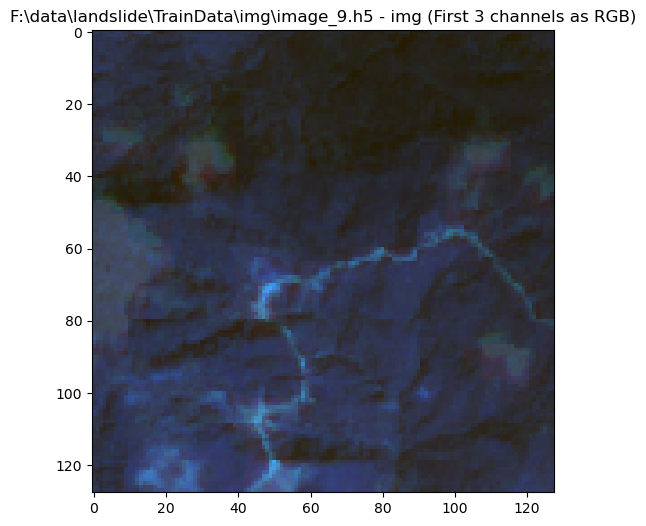

In [40]:
import matplotlib.pyplot as plt

# 选择一个包含1的h5文件来展示
test_file = "F:\data\landslide\TrainData\img\image_9.h5"
print(f"打开文件: {test_file}")

with h5py.File(test_file, "r") as f:
    print(f"文件包含的数据集: {list(f.keys())}")
    
    # 遍历并展示所有数据集
    for key in f.keys():
        data = f[key][:]
        print(f"\n数据集 '{key}' 的形状: {data.shape}, 数据类型: {data.dtype}")
        
        # 如果是图片数据（2D或3D数组）

        if len(data.shape) == 2:
            # 灰度图 - 标准化到0-1范围
            data_display = data.astype(float)
            if data_display.max() > 1:
                data_display = data_display / 255.0
            plt.figure(figsize=(8, 6))
            plt.imshow(data_display, cmap='gray')
            plt.title(f"{test_file} - {key}")
            plt.colorbar()
            plt.show()
        elif len(data.shape) == 3:
            # RGB或多通道图
            if data.shape[2] == 3:
                # 标准化到0-1范围用于显示
                data_display = data.astype(float)
                if data_display.max() > 1:
                    data_display = data_display / 255.0
                plt.figure(figsize=(8, 6))
                plt.imshow(data_display)  # 彩色显示
                plt.title(f"{test_file} - {key}")
                plt.show()
            else:
                # 其他多通道数据，取前3个通道作为RGB显示
                data_display = data[:, :, :3].astype(float)
                # 标准化到0-1范围
                data_min = data_display.min()
                data_max = data_display.max()
                if data_max > data_min:
                    data_display = (data_display - data_min) / (data_max - data_min)
                print(f"  数据范围: [{data_min}, {data_max}]")
                plt.figure(figsize=(8, 6))
                plt.imshow(data_display)  # 取前3个通道作为RGB彩色显示
                plt.title(f"{test_file} - {key} (First 3 channels as RGB)")
                plt.show()
        else:
            print(f"  数据维度为 {len(data.shape)}D，无法直接可视化")


打开文件: F:\data\landslide\TrainData\img\image_9.h5

数据集 'img' 的形状: (128, 128, 14)


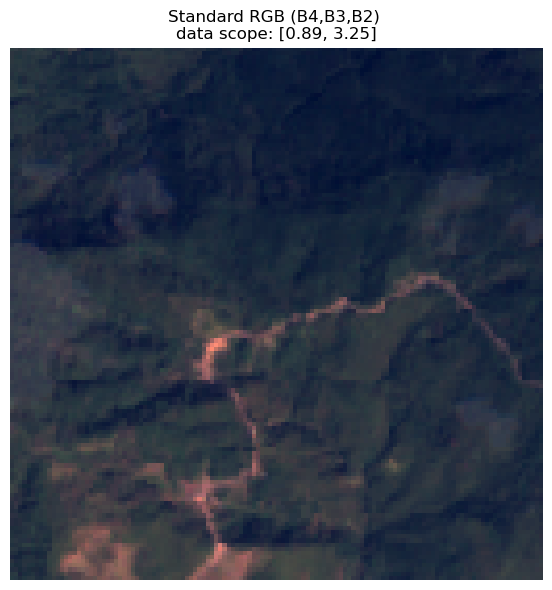

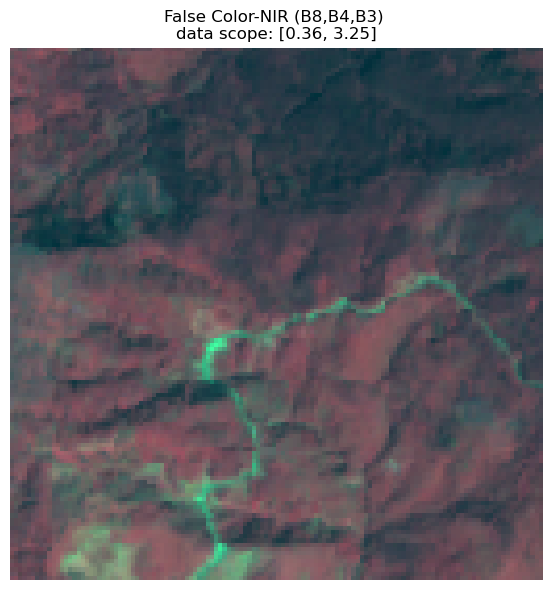

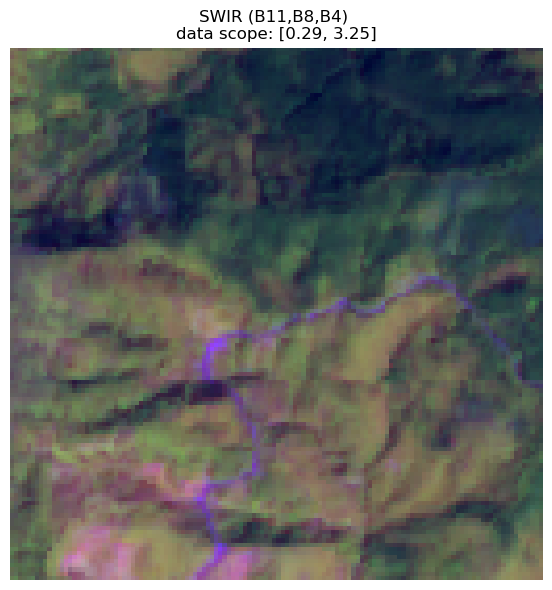

In [44]:
# 14个波段说明：
# Sentinel-2多光谱数据 (Band 1-12):
#   B1 = Coastal aerosol (蓝边界)
#   B2 = Blue (蓝色)
#   B3 = Green (绿色)
#   B4 = Red (红色)
#   B5-B7 = Vegetation Red Edge (植被红边)
#   B8 = NIR (近红外)
#   B9 = Water vapour (水汽)
#   B10 = SWIR - Cirrus (短波红外)
#   B11 = SWIR (短波红外)
#   B12 = SWIR (短波红外)
# B13 = Slope (斜坡)
# B14 = DEM (数字高程模型)

# 标准RGB组合：
# - RGB = B4, B3, B2 (对应数据索引: 3, 2, 1)
# - False Color (植被) = B8, B4, B3 (近红外, 红, 绿, 索引: 7, 3, 2)
# - SWIR组合 = B11, B8, B4 (短波红外, 近红外, 红, 索引: 10, 7, 3)

test_file = "F:\data\landslide\TrainData\img\image_9.h5"
print(f"打开文件: {test_file}")

# 官方数据的均值和标准差
mean = [-0.4914, -0.3074, -0.1277, -0.0625, 0.0439, 0.0803, 0.0644, 0.0802, 0.3000, 0.4082, 0.0823, 0.0516, 0.3338, 0.7819]
std = [0.9325, 0.8775, 0.8860, 0.8869, 0.8857, 0.8418, 0.8354, 0.8491, 0.9061, 1.6072, 0.8848, 0.9232, 0.9018, 1.2913]

with h5py.File(test_file, "r") as f:
    for key in f.keys():
        data = f[key][:]
        print(f"\n数据集 '{key}' 的形状: {data.shape}")
        
        if len(data.shape) == 3 and data.shape[2] >= 14:
            # 转为(C, H, W)格式进行标准化
            data_transposed = np.transpose(data, (2, 0, 1))  # (128, 128, 14) -> (14, 128, 128)
            
            # 应用官方的标准化处理
            data_normalized = data_transposed.copy().astype(float)
            for i in range(len(mean)):
                data_normalized[i, :, :] -= mean[i]
                data_normalized[i, :, :] /= std[i]
            
            # 转回(H, W, C)格式
            data_normalized = np.transpose(data_normalized, (1, 2, 0))
            
            # 构造三种RGB组合
            combinations = {
                'Standard RGB (B4,B3,B2)': [3, 2, 1],  # Red, Green, Blue
                'False Color-NIR (B8,B4,B3)': [7, 3, 2],  # NIR, Red, Green - 植被显示红色
                'SWIR (B11,B8,B4)': [10, 7, 3]  # SWIR, NIR, Red - 显示矿物和植被
            }
            
            for combo_name, band_indices in combinations.items():
                # 提取指定波段
                rgb_data = data_normalized[:, :, band_indices].astype(float)
                
                # Min-Max标准化到0-1用于显示
                data_min = rgb_data.min()
                data_max = rgb_data.max()
                if data_max > data_min:
                    rgb_data = (rgb_data - data_min) / (data_max - data_min)
                
                plt.figure(figsize=(8, 6))
                plt.imshow(rgb_data)
                plt.title(f"{combo_name} \ndata scope: [{data_min:.2f}, {data_max:.2f}]")
                plt.axis('off')
                plt.tight_layout()
                plt.show()
        else:
            print(f"  不是14波段数据或数据形状不符合要求")

In [35]:
# 统计所有img文件中，'img'数据集第二个通道(索引1)的最大值
folder_path = r"F:/data/landslide/ValidData/img"

print(f"扫描文件夹: {folder_path}\n")

band_2_max_values = []

for file in os.listdir(folder_path):
    if file.endswith('.h5'):
        file_path = os.path.join(folder_path, file)
        
        try:
            with h5py.File(file_path, "r") as f:
                if 'img' in f.keys():
                    data = f['img'][:]
                    
                    # 检查是否是14波段数据
                    if len(data.shape) == 3 and data.shape[2] >= 2:
                        # 获取第二个通道(索引1)
                        band_2 = data[:, :, 1]
                        band_2_max = band_2.max()
                        band_2_min = band_2.min()
                        band_2_mean = band_2.mean()
                        
                        band_2_max_values.append(band_2_max)
                        # print(f"{file:30} | Band 2 Max: {band_2_max:10.2f} | Min: {band_2_min:10.2f} | Mean: {band_2_mean:10.2f}")
        except Exception as e:
            print(f"❌ {file}: 读取出错 - {e}")

if band_2_max_values:
    print(f"\n{'='*80}")
    print(f"统计结果 (第二个通道):")
    print(f"  整体最大值: {max(band_2_max_values):.2f}")
    print(f"  整体最小值: {min(band_2_max_values):.2f}")
    print(f"  平均最大值: {np.mean(band_2_max_values):.2f}")
    print(f"  标准差: {np.std(band_2_max_values):.2f}")
    print(f"  扫描的文件数: {len(band_2_max_values)}")
else:
    print("未找到包含'img'数据的h5文件")

扫描文件夹: F:/data/landslide/ValidData/img


统计结果 (第二个通道):
  整体最大值: 4.08
  整体最小值: 1.04
  平均最大值: 1.65
  标准差: 0.37
  扫描的文件数: 245


打开文件: F:\data\landslide\TestData\img\image_9.h5


d:\01_python\Anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38500 (\N{CJK UNIFIED IDEOGRAPH-9664}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\01_python\Anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


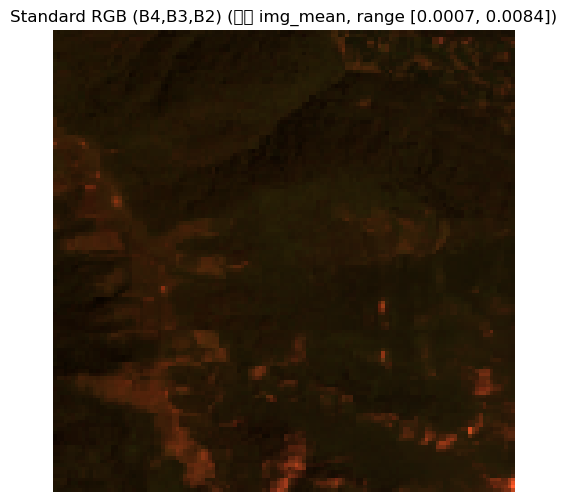

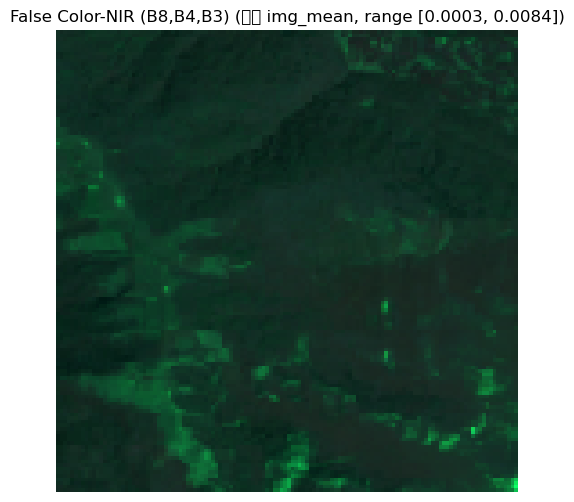

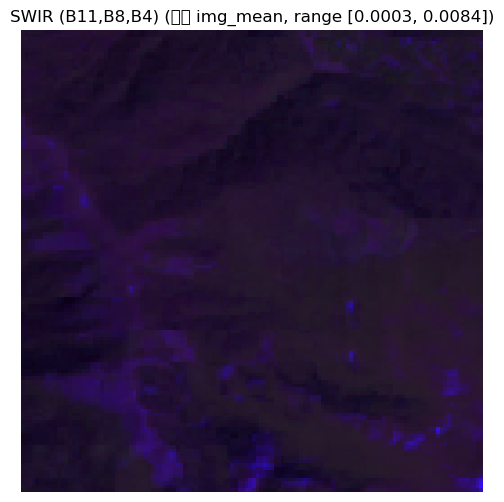

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# 使用 img_mean 按波段除法归一化并展示 RGB（每个波段除以给定均值）
img_mean = [1111.81236406, 824.63171476, 663.41636217, 445.17289745, 645.8582926,
            1547.73508126, 1960.44401001, 1941.32229668, 674.07572865, 9.04787384,
            1113.98338755, 519.90397929, 20.29228266, 772.83144788]

test_file = r"F:\data\landslide\TestData\img\image_9.h5"
print(f"打开文件: {test_file}")

with h5py.File(test_file, 'r') as f:
    if 'img' not in f:
        print("未找到 'img' 数据集")
    else:
        data = f['img'][:].astype(float)  # H,W,C (128,128,14)
        h, w, c = data.shape
        if c < len(img_mean):
            print(f"警告: 数据通道数 ({c}) 少于 img_mean 长度 ({len(img_mean)})")

        # 每个波段除以对应均值
        for i in range(min(c, len(img_mean))):
            data[:, :, i] = data[:, :, i] / img_mean[i]

        # 构造并显示常用RGB组合
        combinations = {
            'Standard RGB (B4,B3,B2)': [3, 2, 1],
            'False Color-NIR (B8,B4,B3)': [7, 3, 2],
            'SWIR (B11,B8,B4)': [10, 7, 3]
        }

        for name, bands in combinations.items():
            # 跳过超出通道数的组合
            if max(bands) >= c:
                print(f"跳过 {name}: 需要的波段超出范围")
                continue

            rgb = data[:, :, bands].astype(float)
            # min-max 归一化到 0-1 以便可视化
            mn, mx = rgb.min(), rgb.max()
            if mx > mn:
                rgb = (rgb - mn) / (mx - mn)

            plt.figure(figsize=(6, 6))
            plt.imshow(rgb)
            plt.title(f"{name} (除以 img_mean, range [{mn:.4f}, {mx:.4f}])")
            plt.axis('off')
            plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


ls ['img']
input data shape: (128, 128, 14)


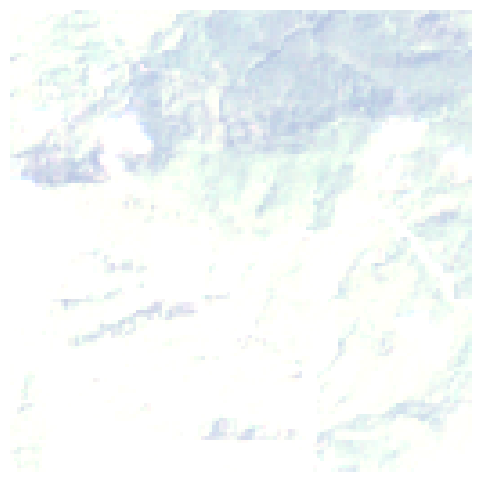

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


data ndvi shape (128, 128) f_data shape: (1, 128, 128, 3)


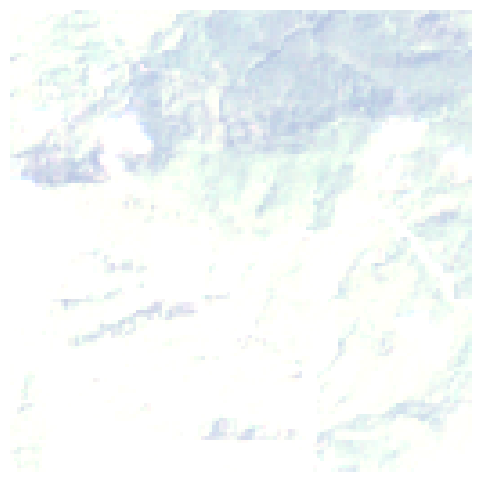

In [42]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# 按用户要求的方法读取单个 h5 文件，计算 NDVI 并构造 f_data
path_single = r"F:\data\landslide\TrainData\img\image_9.h5"

f_data = np.zeros((1, 128, 128, 3))
with h5py.File(path_single, 'r') as hdf:
    ls = list(hdf.keys())
    print("ls", ls)
    data = np.array(hdf.get('img'))  # 形状 (128,128,14)
    print("input data shape:", data.shape)

    # 取 RGB (B4,B3,B2) 顺序为 data[:,:,3],data[:,:,2],data[:,:,1]
    data_rgb = data[:, :, 3:0:-1]
    plt.figure(figsize=(6,6))
    plt.imshow(data_rgb)
    plt.axis('off')
    plt.show()

    # 提取波段
    data_red = data[:, :, 3]
    data_green = data[:, :, 2]
    data_blue = data[:, :, 1]
    data_nir = data[:, :, 7]

    # 计算 NDVI，避免除零
    denom = (data_nir + data_red)
    data_ndvi = np.zeros_like(data_nir, dtype=float)
    mask = denom != 0
    data_ndvi[mask] = (data_nir[mask] - data_red[mask]) / denom[mask]

    # 构造 f_data
    f_data[0, :, :, 0] = data_ndvi
    f_data[0, :, :, 1] = data[:, :, 12]  # B13 or specified band
    f_data[0, :, :, 2] = data[:, :, 13]  # B14 or specified band

    print("data ndvi shape", data_ndvi.shape, "f_data shape:", f_data.shape)

    # 再次展示 RGB
    plt.figure(figsize=(6,6))
    plt.imshow(data_rgb)
    plt.axis('off')
    plt.show()